In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("supermarket_sales.csv")
df

,OrderID,Product,Category,City,Sales,Profit,Quantity
0,1,Laptop,Electronics,Chennai,50000,8000,2
1,2,Mouse,Electronics,Bangalore,700,150,5
2,3,Chair,Furniture,Chennai,3500,500,1
3,4,Table,Furniture,Mumbai,7000,1000,2
4,5,Phone,Electronics,Delhi,25000,5000,3
5,6,Sofa,Furniture,Bangalore,12000,2500,1
6,7,Keyboard,Electronics,Delhi,1500,300,4
7,8,Desk,Furniture,Chennai,6500,1200,2
8,9,Tablet,Electronics,Mumbai,18000,3500,2
9,10,Lamp,Furniture,Delhi,900,200,6


In [ ]:
df.head()

,OrderID,Product,Category,City,Sales,Profit,Quantity
0,1,Laptop,Electronics,Chennai,50000,8000,2
1,2,Mouse,Electronics,Bangalore,700,150,5
2,3,Chair,Furniture,Chennai,3500,500,1
3,4,Table,Furniture,Mumbai,7000,1000,2
4,5,Phone,Electronics,Delhi,25000,5000,3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   OrderID   10 non-null     int64 
 1   Product   10 non-null     object
 2   Category  10 non-null     object
 3   City      10 non-null     object
 4   Sales     10 non-null     int64 
 5   Profit    10 non-null     int64 
 6   Quantity  10 non-null     int64 
dtypes: int64(4), object(3)
memory usage: 692.0+ bytes


In [ ]:
df.describe()

,OrderID,Sales,Profit,Quantity
count,10.00000,10.000000,10.000000,10.000000
mean,5.50000,12510.000000,2235.000000,2.800000
std,3.02765,15402.196813,2590.372131,1.686548
min,1.00000,700.000000,150.000000,1.000000
25%,3.25000,2000.000000,350.000000,2.000000
50%,5.50000,6750.000000,1100.000000,2.000000
75%,7.75000,16500.000000,3250.000000,3.750000
max,10.00000,50000.000000,8000.000000,6.000000


In [ ]:
df.isnull().sum()

,0
OrderID,0
Product,0
Category,0
City,0
Sales,0
Profit,0
Quantity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

FIND TOTAL SALES

In [ ]:
df["Sales"].sum()

np.int64(125100)

FIND TOTAL PROFIT

In [ ]:
df["Profit"].sum()

np.int64(22350)

FIND TOTAL QTY

In [ ]:
df["Quantity"].sum()

np.int64(28)

CREATE NEW COLNS


PROFIT PER ITEM

In [ ]:
df["Profit_Per_Item"]=df["Profit"]/df["Quantity"]

In [ ]:
df

,OrderID,Product,Category,City,Sales,Profit,Quantity,Profit_Per_Item
0,1,Laptop,Electronics,Chennai,50000,8000,2,4000.000000
1,2,Mouse,Electronics,Bangalore,700,150,5,30.000000
2,3,Chair,Furniture,Chennai,3500,500,1,500.000000
3,4,Table,Furniture,Mumbai,7000,1000,2,500.000000
4,5,Phone,Electronics,Delhi,25000,5000,3,1666.666667
5,6,Sofa,Furniture,Bangalore,12000,2500,1,2500.000000
6,7,Keyboard,Electronics,Delhi,1500,300,4,75.000000
7,8,Desk,Furniture,Chennai,6500,1200,2,600.000000
8,9,Tablet,Electronics,Mumbai,18000,3500,2,1750.000000
9,10,Lamp,Furniture,Delhi,900,200,6,33.333333


AVG_SALES

In [ ]:
df["AVG_SALES"]=df.groupby("Category")["Sales"].transform("mean")
df

,OrderID,Product,Category,City,Sales,Profit,Quantity,Profit_Per_Item,AVG_SALES
0,1,Laptop,Electronics,Chennai,50000,8000,2,4000.000000,19040.0
1,2,Mouse,Electronics,Bangalore,700,150,5,30.000000,19040.0
2,3,Chair,Furniture,Chennai,3500,500,1,500.000000,5980.0
3,4,Table,Furniture,Mumbai,7000,1000,2,500.000000,5980.0
4,5,Phone,Electronics,Delhi,25000,5000,3,1666.666667,19040.0
5,6,Sofa,Furniture,Bangalore,12000,2500,1,2500.000000,5980.0
6,7,Keyboard,Electronics,Delhi,1500,300,4,75.000000,19040.0
7,8,Desk,Furniture,Chennai,6500,1200,2,600.000000,5980.0
8,9,Tablet,Electronics,Mumbai,18000,3500,2,1750.000000,19040.0
9,10,Lamp,Furniture,Delhi,900,200,6,33.333333,5980.0


GROUPBY ANALYSIS

SALES BY CITY

In [ ]:
df.groupby("City")["Sales"].sum()

,Sales
City,
Bangalore,12700
Chennai,60000
Delhi,27400
Mumbai,25000


PROFIT BY CATEGORY

In [ ]:
df.groupby("Category")["Profit"].sum()

,Profit
Category,
Electronics,16950
Furniture,5400


QTY BY PRODUCT

In [ ]:
df.groupby("Product")["Quantity"].sum().idxmax()

'Lamp'

SORTING

WHICH PRODUCT HAS HIGHEST SALES?

In [ ]:
 df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

,Sales
Product,
Laptop,50000
Phone,25000
Tablet,18000
Sofa,12000
Table,7000
Desk,6500
Chair,3500
Keyboard,1500
Lamp,900


FIND CITY WITH MAX SALES

In [ ]:
df.groupby("City")["Sales"].sum().idxmax()

'Chennai'

PRODUCT WITH MAX PROFIT

In [ ]:
df.groupby("Product")["Profit"].sum().idxmax()

'Laptop'

VISUALIZATION

In [ ]:
import matplotlib.pyplot as plt


Text(0, 0.5, 'SALES')

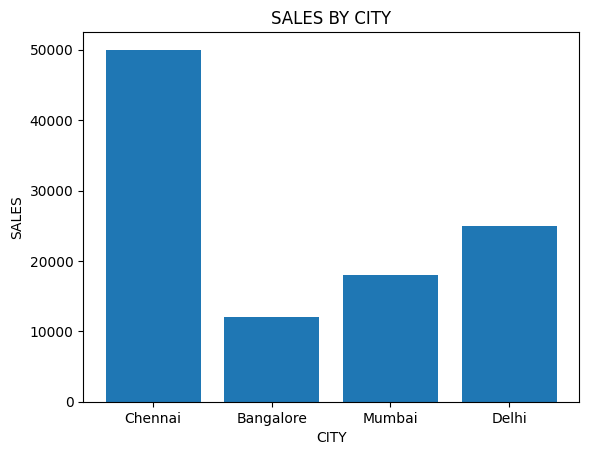

In [ ]:
plt.bar(df["City"],df["Sales"])
plt.title("SALES BY CITY")
plt.xlabel("CITY")
plt.ylabel("SALES")

PIE CHART
CATEGORY SALES SHARE

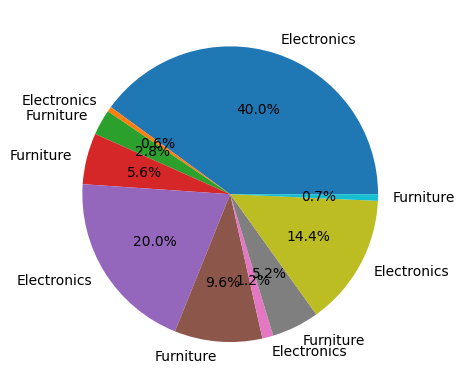

In [ ]:
plt.pie(df['Sales'],labels=df['Category'],autopct='%1.1f%%')
plt.show()

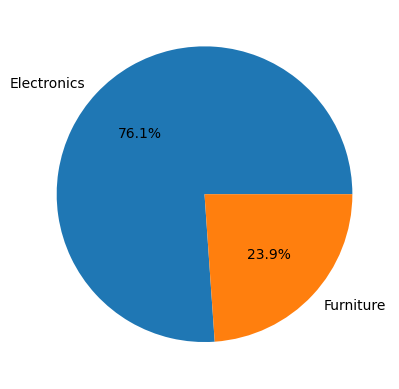

In [ ]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%')
plt.show()

**INSIGHTS**
1.CITY WITH MAX SALES = CHENNAI SO INCREASE PRODUCTS IN CHENNAI
2.PRODUCT WITH MAX PROFIT = LAPTOP..GIVE MORE ADS..
3.INCREASE STOCKS IN ELECTRONICS AND GIVE MORE IDEAS ON IMPROVING FURNITURE SALES..
4.

In [ ]:
df.to_csv("supermarket_sales_updated.csv", index=False)

In [ ]:
from google.colab import files
files.download("supermarket_sales_updated.csv")

mean() → summary only

transform("mean") → repeat result row-wise
Need grouped calculation
+
Need result for every row

## Insights

1. Chennai has the highest sales among all cities.

2. Electronics category contributes highest revenue and profit.

3. Laptop is the most profitable product.

4. Furniture category has comparatively lower sales and profit.

## Recommendations

1. Increase inventory for Electronics products.

2. Focus more advertisements on Laptop and Phone products.

3. Introduce discounts/offers to improve Furniture sales.

4. Expand marketing campaigns in Chennai.